In [66]:
import pandas as pd
import os

features_dir = "../data/processed/features"

regions = [
    "AEP",
    "COMED",
    "DAYTON",
    "DEOK",
    "DOM",
    "DUQ",
    "EKPC",
    "FE",
    "NI",
    "PJME",
    "PJMW"
]

feature_data = {}

for region in regions:
    file_path = os.path.join(
        features_dir,
        f"{region}_features.csv"
    )
    
    df = pd.read_csv(file_path)
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    
    feature_data[region] = df
    
    print(
        region,
        "| rows =", len(df),
        "| columns =", len(df.columns),
        "| NaNs =", df.isna().sum().sum()
    )

AEP | rows = 121105 | columns = 18 | NaNs = 0
COMED | rows = 66329 | columns = 18 | NaNs = 0
DAYTON | rows = 121107 | columns = 18 | NaNs = 0
DEOK | rows = 57571 | columns = 18 | NaNs = 0
DOM | rows = 116021 | columns = 18 | NaNs = 0
DUQ | rows = 118900 | columns = 18 | NaNs = 0
EKPC | rows = 45166 | columns = 18 | NaNs = 0
FE | rows = 62706 | columns = 18 | NaNs = 0
NI | rows = 58282 | columns = 18 | NaNs = 0
PJME | rows = 145198 | columns = 18 | NaNs = 0
PJMW | rows = 143038 | columns = 18 | NaNs = 0


In [83]:
def prepare_region_data(df, region):

    df = df.copy()

    # Make sure datetime is sorted
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values("Datetime").reset_index(drop=True)

    # Create NEXT-HOUR forecasting target
    df["target"] = df[f"{region}_MW"].shift(-1)

    # Features used by XGBoost
    # IMPORTANT: "season" is removed because it is a string column.
    feature_columns = [
        f"{region}_MW",
        "hour",
        "day",
        "day_of_week",
        "month",
        "year",
        "is_weekend",
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_24",
        "lag_48",
        "lag_168",
        "rolling_mean_24",
        "rolling_std_24",
        "rolling_mean_168"
    ]

    # Keep only columns that actually exist
    feature_columns = [
        col for col in feature_columns
        if col in df.columns
    ]

    X = df[feature_columns]
    y = df["target"]

    # Remove rows with missing values
    valid = X.notna().all(axis=1) & y.notna()

    X = X.loc[valid].reset_index(drop=True)
    y = y.loc[valid].reset_index(drop=True)
    df = df.loc[valid].reset_index(drop=True)

    return X, y, df

In [58]:
# Prepare AEP data

X_aep, y_aep, aep_df = prepare_region_data(
    feature_data["AEP"],
    "AEP"
)

print("AEP prepared successfully.")
print("X shape:", X_aep.shape)
print("y shape:", y_aep.shape)

print("\nFeature columns:")
print(X_aep.columns.tolist())

print("\nData types:")
print(X_aep.dtypes)

print("\nAny NaNs in X:", X_aep.isna().sum().sum())
print("Any NaNs in y:", y_aep.isna().sum())

AEP prepared successfully.
X shape: (121104, 16)
y shape: (121104,)

Feature columns:
['AEP_MW', 'hour', 'day', 'day_of_week', 'month', 'year', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168']

Data types:
AEP_MW              float64
hour                  int64
day                   int64
day_of_week           int64
month                 int64
year                  int64
is_weekend            int64
lag_1               float64
lag_2               float64
lag_3               float64
lag_24              float64
lag_48              float64
lag_168             float64
rolling_mean_24     float64
rolling_std_24      float64
rolling_mean_168    float64
dtype: object

Any NaNs in X: 0
Any NaNs in y: 0


In [68]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Train / Validation / Test split
# -----------------------------

n = len(X_aep)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_aep.iloc[:train_end]
y_train = y_aep.iloc[:train_end]

X_val = X_aep.iloc[train_end:val_end]
y_val = y_aep.iloc[train_end:val_end]

X_test = X_aep.iloc[val_end:]
y_test = y_aep.iloc[val_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (84772, 16)
Validation: (18166, 16)
Test: (18166, 16)


In [69]:
from xgboost import XGBRegressor

model_aep = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_aep.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("AEP XGBoost training completed.")

AEP XGBoost training completed.


In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on validation data
val_pred_aep = model_aep.predict(X_val)

# Calculate validation metrics
val_mae_aep = mean_absolute_error(y_val, val_pred_aep)
val_rmse_aep = np.sqrt(mean_squared_error(y_val, val_pred_aep))
val_r2_aep = r2_score(y_val, val_pred_aep)

print("AEP Validation MAE :", val_mae_aep)
print("AEP Validation RMSE:", val_rmse_aep)
print("AEP Validation R²  :", val_r2_aep)

AEP Validation MAE : 108.96546782321714
AEP Validation RMSE: 148.64341467310263
AEP Validation R²  : 0.996456249775008


In [71]:
test_pred_aep = model_aep.predict(X_test)

test_mae_aep = mean_absolute_error(y_test, test_pred_aep)
test_rmse_aep = np.sqrt(mean_squared_error(y_test, test_pred_aep))
test_r2_aep = r2_score(y_test, test_pred_aep)

print("AEP Test MAE :", test_mae_aep)
print("AEP Test RMSE:", test_rmse_aep)
print("AEP Test R²  :", test_r2_aep)

AEP Test MAE : 115.88436179710723
AEP Test RMSE: 154.72785137079484
AEP Test R²  : 0.9961268124217674


In [72]:
# Create AEP test prediction results

aep_test_results = aep_df.iloc[val_end:].copy()

aep_test_results["Actual"] = y_test.values
aep_test_results["Predicted"] = test_pred_aep

print("AEP test prediction results:")
print(aep_test_results[[
    "Datetime",
    "Actual",
    "Predicted"
]].head(10))

AEP test prediction results:
                  Datetime   Actual     Predicted
102938 2016-07-07 02:00:00  12922.0  12949.261719
102939 2016-07-07 03:00:00  12655.0  12568.829102
102940 2016-07-07 04:00:00  12626.0  12572.396484
102941 2016-07-07 05:00:00  13044.0  13013.305664
102942 2016-07-07 06:00:00  13631.0  13859.071289
102943 2016-07-07 07:00:00  14566.0  14501.320312
102944 2016-07-07 08:00:00  15306.0  15285.658203
102945 2016-07-07 09:00:00  15979.0  15993.826172
102946 2016-07-07 10:00:00  16815.0  16772.642578
102947 2016-07-07 11:00:00  17697.0  17581.996094


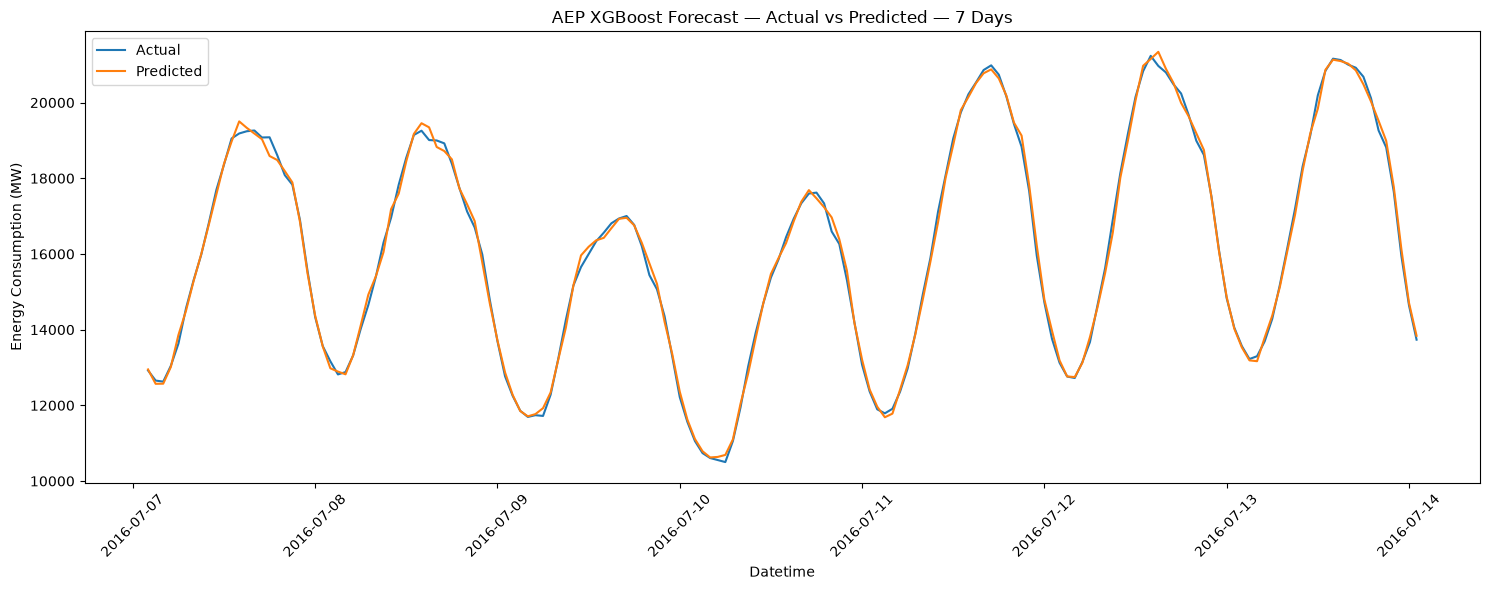

In [73]:
import matplotlib.pyplot as plt

plot_data = aep_test_results.head(24 * 7)

plt.figure(figsize=(15, 6))

plt.plot(
    plot_data["Datetime"],
    plot_data["Actual"],
    label="Actual"
)

plt.plot(
    plot_data["Datetime"],
    plot_data["Predicted"],
    label="Predicted"
)

plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.title("AEP XGBoost Forecast — Actual vs Predicted — 7 Days")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save AEP model
aep_model_path = "../models/xgboost_AEP_model.pkl"

joblib.dump(model_aep, aep_model_path)

print("AEP model saved successfully.")
print("Path:", aep_model_path)

AEP model saved successfully.
Path: ../models/xgboost_AEP_model.pkl


In [75]:
print(os.path.exists(aep_model_path))

True


In [76]:
import pandas as pd
import numpy as np
import os
import joblib

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [77]:
regions_to_redo = [
    "COMED",
    "DAYTON",
    "DEOK",
    "DOM",
    "DUQ",
    "EKPC",
    "FE",
    "NI",
    "PJMW"
]

features_dir = "../data/processed/features"
regional_model_dir = "../models/regional"
prediction_dir = "../data/processed/predictions"

os.makedirs(regional_model_dir, exist_ok=True)
os.makedirs(prediction_dir, exist_ok=True)

print("Regions to redo:")
print(regions_to_redo)

print("\nModel directory:")
print(os.path.abspath(regional_model_dir))

print("\nPrediction directory:")
print(os.path.abspath(prediction_dir))

Regions to redo:
['COMED', 'DAYTON', 'DEOK', 'DOM', 'DUQ', 'EKPC', 'FE', 'NI', 'PJMW']

Model directory:
c:\Users\sukhy\Desktop\smart-energy-project\models\regional

Prediction directory:
c:\Users\sukhy\Desktop\smart-energy-project\data\processed\predictions


In [78]:
def prepare_region_data(df, region):

    df = df.copy()

    # Make sure datetime is sorted
    df["Datetime"] = pd.to_datetime(df["Datetime"])
    df = df.sort_values("Datetime").reset_index(drop=True)

    # Create NEXT-HOUR forecasting target
    df["target"] = df[f"{region}_MW"].shift(-1)

    # Features used by XGBoost
    feature_columns = [
        f"{region}_MW",
        "hour",
        "day",
        "day_of_week",
        "month",
        "year",
        "is_weekend",
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_24",
        "lag_48",
        "lag_168",
        "rolling_mean_24",
        "rolling_std_24",
        "rolling_mean_168"
    ]

    # Keep only columns that exist
    feature_columns = [
        col for col in feature_columns
        if col in df.columns
    ]

    X = df[feature_columns]
    y = df["target"]

    # Remove rows containing missing values
    valid = X.notna().all(axis=1) & y.notna()

    X = X.loc[valid].reset_index(drop=True)
    y = y.loc[valid].reset_index(drop=True)
    df = df.loc[valid].reset_index(drop=True)

    return X, y, df

In [79]:
def time_series_split(X, y, df):

    n = len(X)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_val = X.iloc[train_end:val_end]
    y_val = y.iloc[train_end:val_end]

    X_test = X.iloc[val_end:]
    y_test = y.iloc[val_end:]

    df_train = df.iloc[:train_end]
    df_val = df.iloc[train_end:val_end]
    df_test = df.iloc[val_end:]

    return (
        X_train, X_val, X_test,
        y_train, y_val, y_test,
        df_train, df_val, df_test
    )

In [80]:
results = {}
trained_models = {}
test_predictions = {}

for region in regions_to_redo:

    print("\n" + "=" * 60)
    print(f"TRAINING {region}")
    print("=" * 60)

    # --------------------------------------------------
    # Load feature data
    # --------------------------------------------------

    file_path = os.path.join(
        features_dir,
        f"{region}_features.csv"
    )

    df = pd.read_csv(file_path)

    print("Rows loaded:", len(df))

    # --------------------------------------------------
    # Prepare data
    # --------------------------------------------------

    X, y, prepared_df = prepare_region_data(
        df,
        region
    )

    print("Prepared X:", X.shape)
    print("Prepared y:", y.shape)

    # --------------------------------------------------
    # Train / Validation / Test split
    # --------------------------------------------------

    (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test,
        df_train,
        df_val,
        df_test
    ) = time_series_split(
        X,
        y,
        prepared_df
    )

    print("Train:", X_train.shape)
    print("Validation:", X_val.shape)
    print("Test:", X_test.shape)

    # --------------------------------------------------
    # Create XGBoost model
    # --------------------------------------------------

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    # --------------------------------------------------
    # Train
    # --------------------------------------------------

    model.fit(
        X_train,
        y_train
    )

    # --------------------------------------------------
    # Validation prediction
    # --------------------------------------------------

    val_pred = model.predict(X_val)

    val_mae = mean_absolute_error(
        y_val,
        val_pred
    )

    val_rmse = np.sqrt(
        mean_squared_error(
            y_val,
            val_pred
        )
    )

    val_r2 = r2_score(
        y_val,
        val_pred
    )

    # --------------------------------------------------
    # Test prediction
    # --------------------------------------------------

    test_pred = model.predict(X_test)

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    # --------------------------------------------------
    # Save model
    # --------------------------------------------------

    model_path = os.path.join(
        regional_model_dir,
        f"{region}_xgboost_forecasting_model.pkl"
    )

    joblib.dump(
        model,
        model_path
    )

    # --------------------------------------------------
    # Save test predictions
    # --------------------------------------------------

    prediction_df = pd.DataFrame({
        "Datetime": df_test["Datetime"].values,
        "Actual": y_test.values,
        "Predicted": test_pred
    })

    prediction_path = os.path.join(
        prediction_dir,
        f"{region}_predictions.csv"
    )

    prediction_df.to_csv(
        prediction_path,
        index=False
    )

    # --------------------------------------------------
    # Store results
    # --------------------------------------------------

    results[region] = {
        "Validation MAE": val_mae,
        "Validation RMSE": val_rmse,
        "Validation R2": val_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R2": test_r2
    }

    trained_models[region] = model
    test_predictions[region] = prediction_df

    print(f"\n{region} Validation MAE  : {val_mae:.2f}")
    print(f"{region} Validation RMSE : {val_rmse:.2f}")
    print(f"{region} Validation R2   : {val_r2:.4f}")

    print(f"\n{region} Test MAE        : {test_mae:.2f}")
    print(f"{region} Test RMSE       : {test_rmse:.2f}")
    print(f"{region} Test R2         : {test_r2:.4f}")

    print(f"\nModel saved -> {model_path}")
    print(f"Predictions saved -> {prediction_path}")


TRAINING COMED
Rows loaded: 66329
Prepared X: (66328, 16)
Prepared y: (66328,)
Train: (46429, 16)
Validation: (9949, 16)
Test: (9950, 16)

COMED Validation MAE  : 90.55
COMED Validation RMSE : 134.52
COMED Validation R2   : 0.9969

COMED Test MAE        : 90.05
COMED Test RMSE       : 132.28
COMED Test R2         : 0.9966

Model saved -> ../models/regional\COMED_xgboost_forecasting_model.pkl
Predictions saved -> ../data/processed/predictions\COMED_predictions.csv

TRAINING DAYTON
Rows loaded: 121107
Prepared X: (121106, 16)
Prepared y: (121106,)
Train: (84774, 16)
Validation: (18166, 16)
Test: (18166, 16)

DAYTON Validation MAE  : 15.08
DAYTON Validation RMSE : 21.06
DAYTON Validation R2   : 0.9967

DAYTON Test MAE        : 17.61
DAYTON Test RMSE       : 25.77
DAYTON Test R2         : 0.9955

Model saved -> ../models/regional\DAYTON_xgboost_forecasting_model.pkl
Predictions saved -> ../data/processed/predictions\DAYTON_predictions.csv

TRAINING DEOK
Rows loaded: 57571
Prepared X: (575

In [32]:
results_df = pd.DataFrame(results).T

results_df = results_df[
    [
        "Validation MAE",
        "Validation RMSE",
        "Validation R2",
        "Test MAE",
        "Test RMSE",
        "Test R2"
    ]
]

results_df

,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
COMED,90.549804,134.524025,0.996913,90.050037,132.278233,0.996648
DAYTON,15.083726,21.060124,0.996743,17.606735,25.770482,0.995543
DEOK,27.907831,40.459684,0.995252,34.187908,77.714138,0.983594
DOM,95.569611,147.627979,0.996497,108.095635,174.325592,0.994945
DUQ,18.841794,25.703763,0.992771,18.090391,24.511319,0.993240
EKPC,26.730575,34.996398,0.986331,29.750131,40.792065,0.989472
FE,62.114888,84.696768,0.996490,60.412969,82.149474,0.996019
NI,83.519330,116.076808,0.996701,95.422027,140.401989,0.996879
PJMW,53.960398,86.279424,0.993371,53.797192,77.725165,0.993794


In [23]:
print("Models saved:\n")

for region in regions_to_redo:

    filename = f"{region}_xgboost_forecasting_model.pkl"

    path = os.path.join(
        regional_model_dir,
        filename
    )

    print(
        region,
        "->",
        "OK" if os.path.exists(path) else "MISSING"
    )

Models saved:

COMED -> OK
DAYTON -> OK
DEOK -> OK
DOM -> OK
DUQ -> OK
EKPC -> OK
FE -> OK
NI -> OK
PJMW -> OK


In [33]:
print("Prediction files:\n")

for region in regions_to_redo:

    filename = f"{region}_predictions.csv"

    path = os.path.join(
        prediction_dir,
        filename
    )

    print(
        region,
        "->",
        "OK" if os.path.exists(path) else "MISSING"
    )

Prediction files:

COMED -> OK
DAYTON -> OK
DEOK -> OK
DOM -> OK
DUQ -> OK
EKPC -> OK
FE -> OK
NI -> OK
PJMW -> OK


In [25]:
# Inspect prediction files

for region in regions_to_redo:

    path = os.path.join(
        prediction_dir,
        f"{region}_predictions.csv"
    )

    df_pred = pd.read_csv(path)

    print("\n" + "=" * 50)
    print(region)
    print("=" * 50)

    print("Rows:", len(df_pred))
    print("Columns:", df_pred.columns.tolist())
    print("NaNs:", df_pred.isna().sum().sum())

    print("\nFirst 5 rows:")
    print(df_pred.head())


COMED
Rows: 9950
Columns: ['Datetime', 'Actual', 'Predicted']
NaNs: 0

First 5 rows:
              Datetime   Actual  Predicted
0  2017-06-14 10:00:00  15904.0  15498.490
1  2017-06-14 11:00:00  17137.0  16964.127
2  2017-06-14 12:00:00  18067.0  18072.160
3  2017-06-14 13:00:00  18627.0  18629.904
4  2017-06-14 14:00:00  18973.0  18929.790

DAYTON
Rows: 18166
Columns: ['Datetime', 'Actual', 'Predicted']
NaNs: 0

First 5 rows:
              Datetime  Actual  Predicted
0  2016-07-07 02:00:00  1744.0  1731.3795
1  2016-07-07 03:00:00  1689.0  1687.5089
2  2016-07-07 04:00:00  1694.0  1683.0302
3  2016-07-07 05:00:00  1765.0  1776.7593
4  2016-07-07 06:00:00  1877.0  1910.3926

DEOK
Rows: 8636
Columns: ['Datetime', 'Actual', 'Predicted']
NaNs: 0

First 5 rows:
              Datetime  Actual  Predicted
0  2017-08-08 04:00:00  2370.0  2363.8616
1  2017-08-08 05:00:00  2481.0  2496.9177
2  2017-08-08 06:00:00  2681.0  2684.1620
3  2017-08-08 07:00:00  2754.0  2819.9446
4  2017-08-08 08:00:0

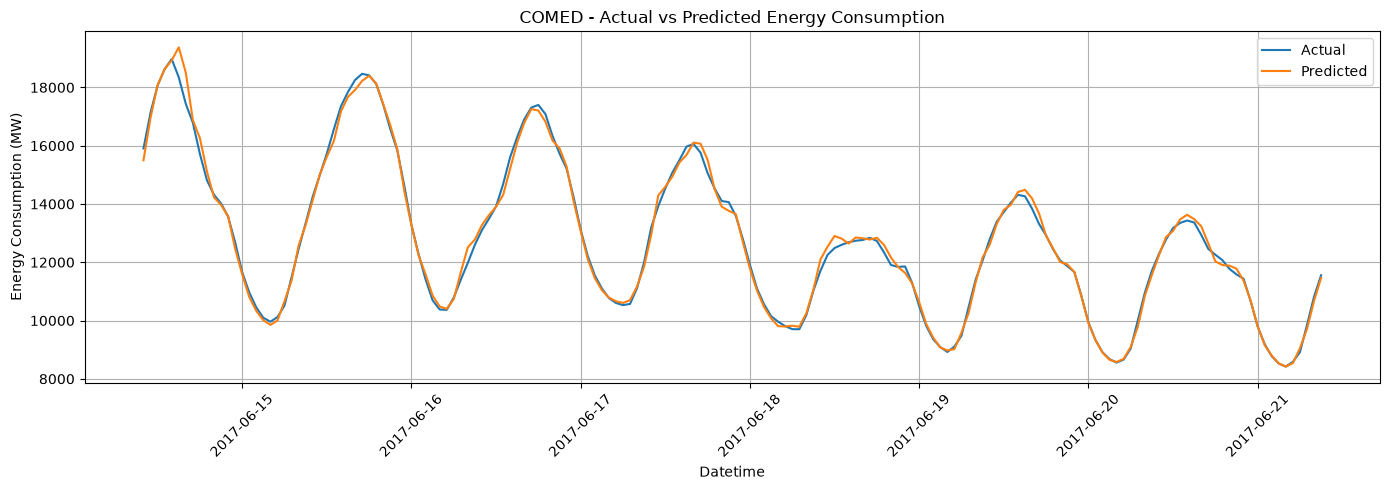

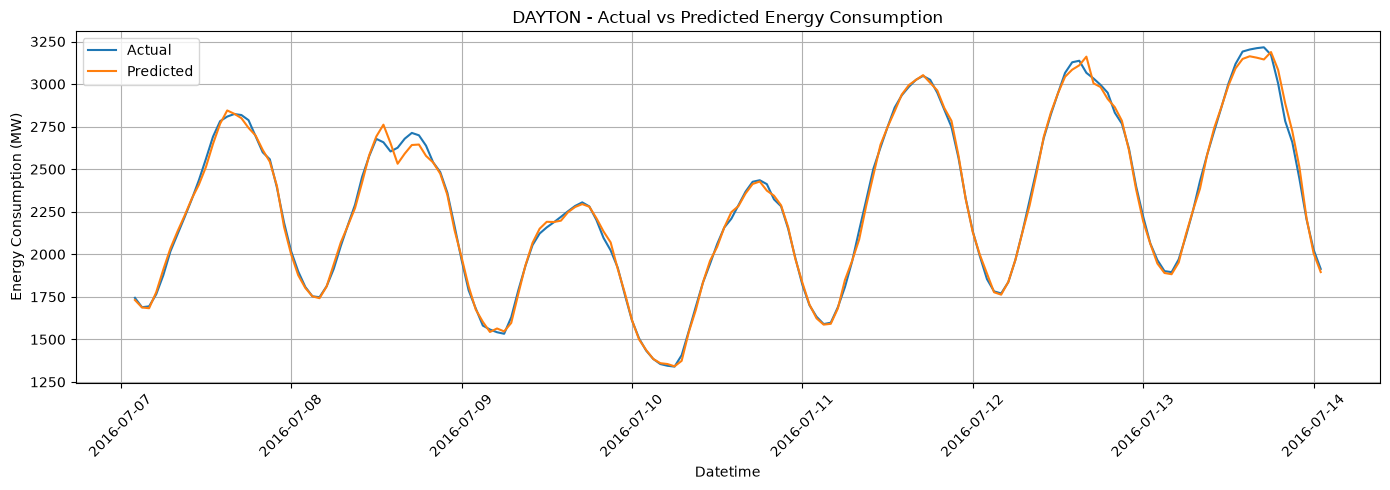

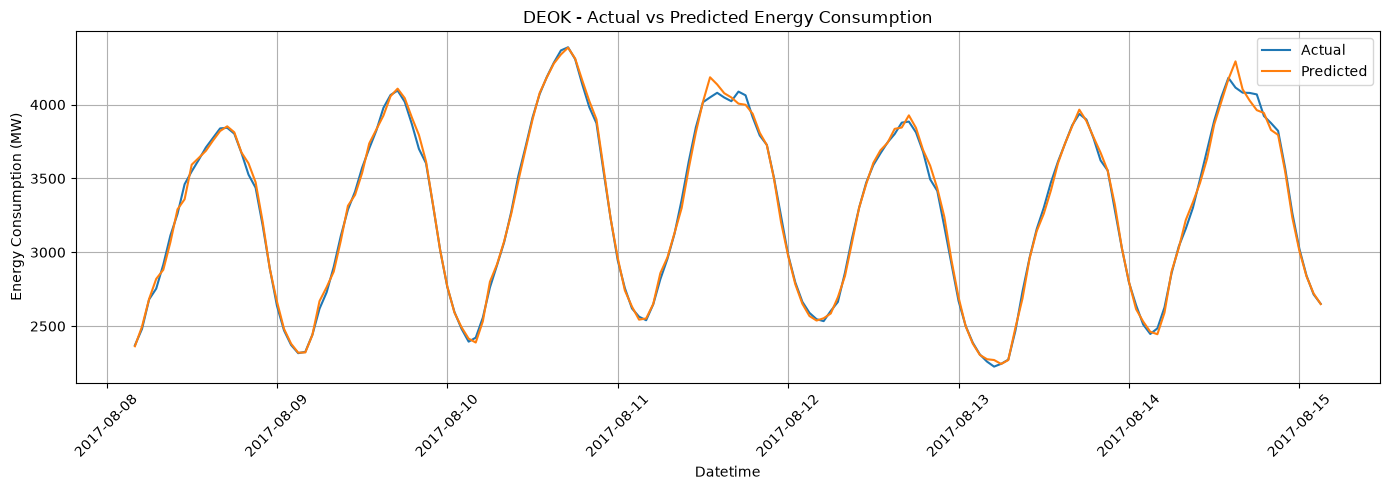

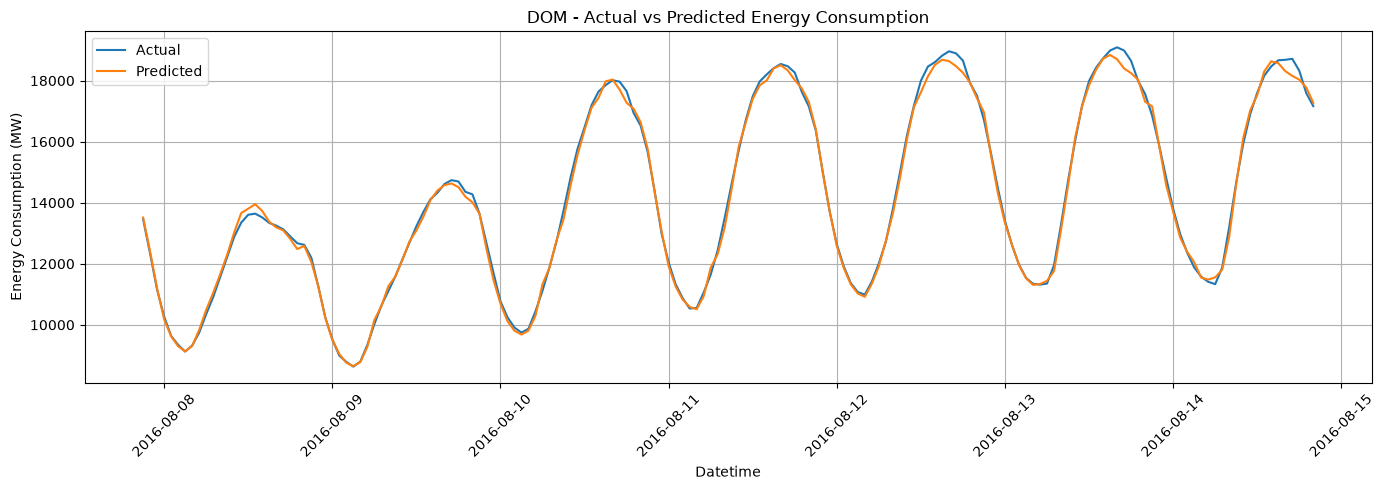

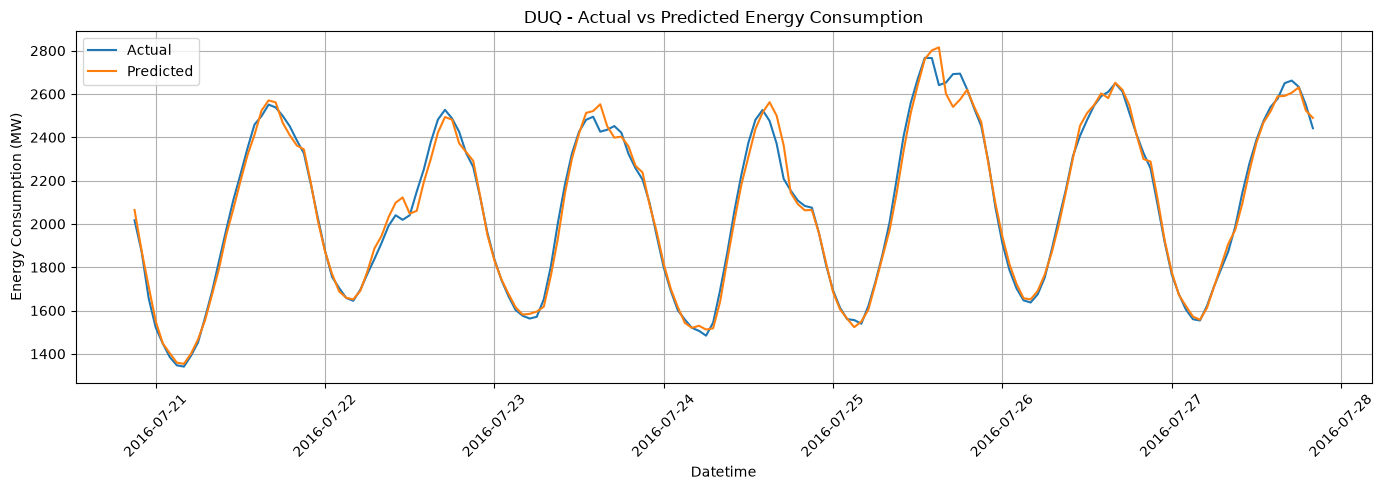

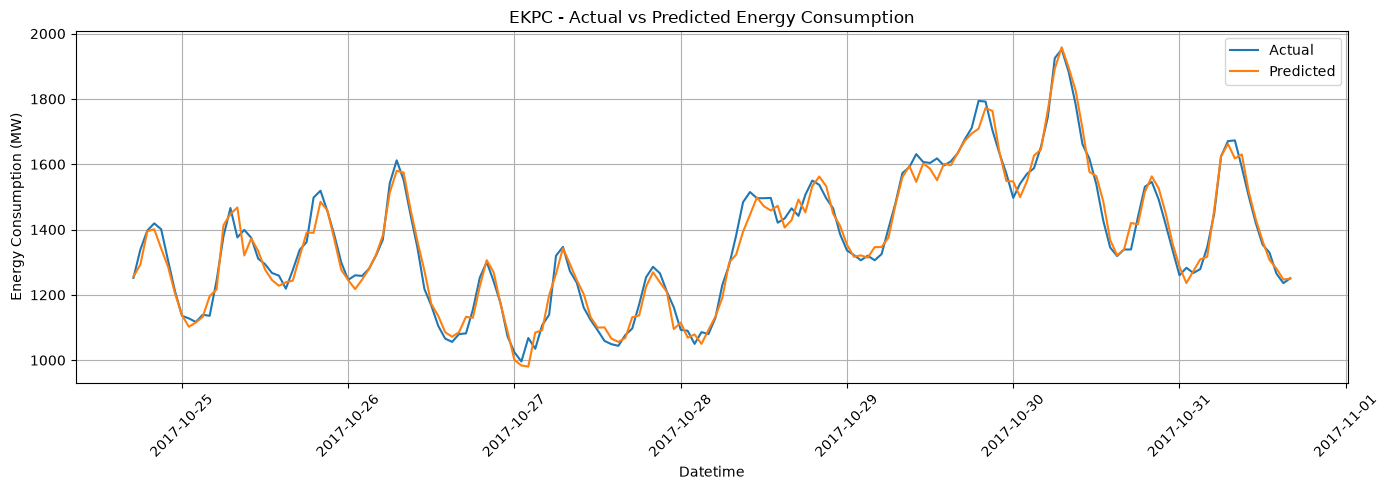

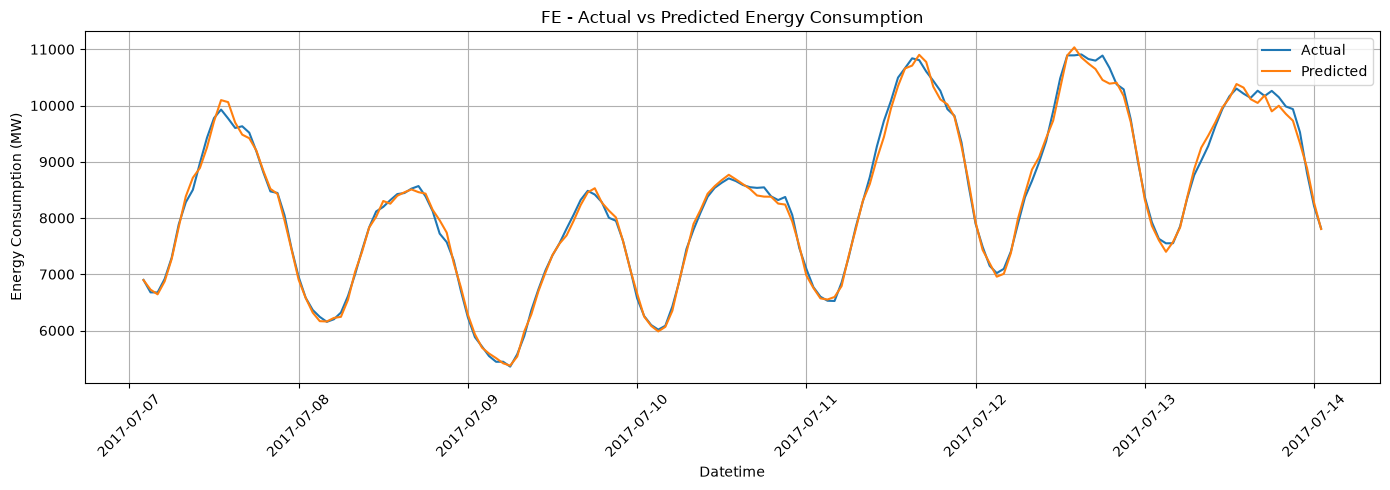

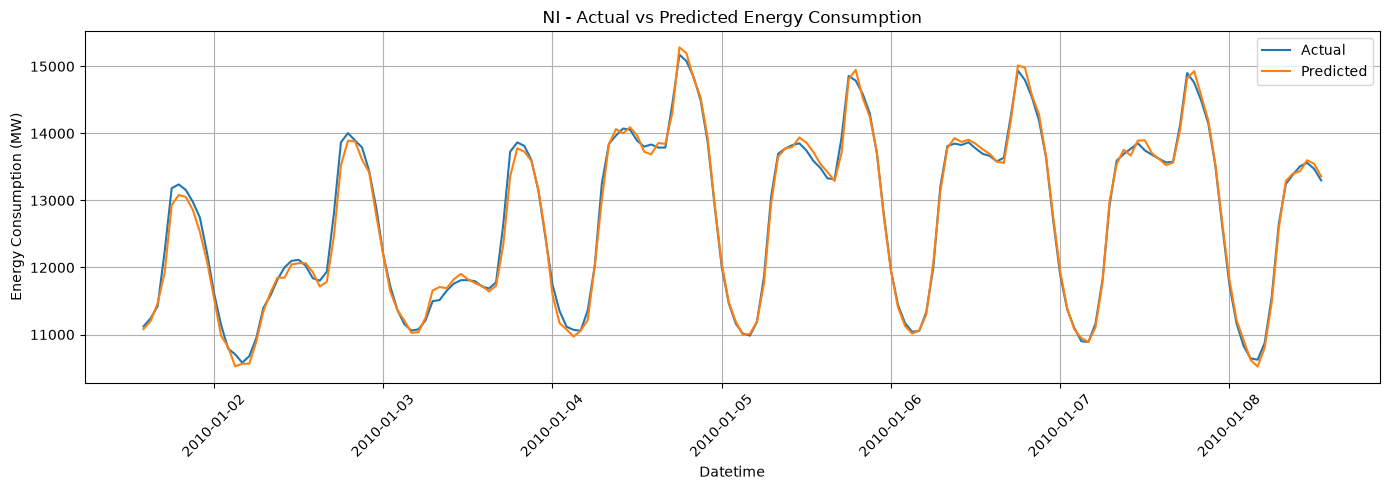

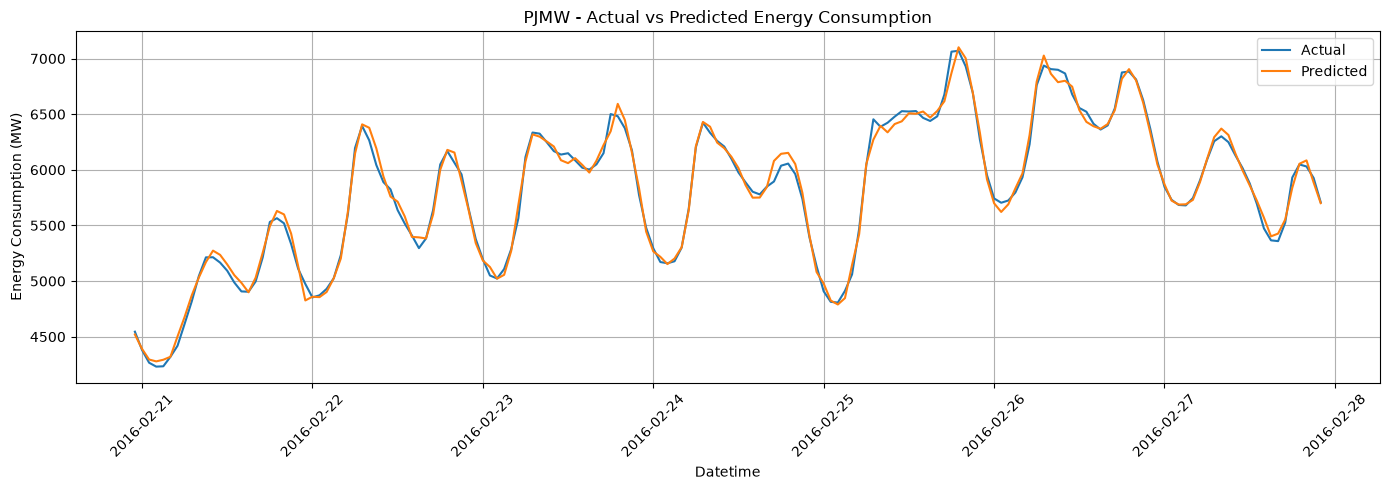

In [53]:
import os
import pandas as pd
import matplotlib.pyplot as plt

prediction_dir = "../data/processed/predictions"

regions_to_plot = [
    "COMED",
    "DAYTON",
    "DEOK",
    "DOM",
    "DUQ",
    "EKPC",
    "FE",
    "NI",
    "PJMW"
]

for region in regions_to_plot:

    file_path = os.path.join(
        prediction_dir,
        f"{region}_predictions.csv"
    )

    df_pred = pd.read_csv(file_path)

    df_pred["Datetime"] = pd.to_datetime(
        df_pred["Datetime"]
    )

    # Plot only first 7 days for readability
    start_date = df_pred["Datetime"].min()
    end_date = start_date + pd.Timedelta(days=7)

    plot_df = df_pred[
        (df_pred["Datetime"] >= start_date) &
        (df_pred["Datetime"] < end_date)
    ]

    plt.figure(figsize=(14, 5))

    plt.plot(
        plot_df["Datetime"],
        plot_df["Actual"],
        label="Actual"
    )

    plt.plot(
        plot_df["Datetime"],
        plot_df["Predicted"],
        label="Predicted"
    )

    plt.title(
        f"{region} - Actual vs Predicted Energy Consumption"
    )

    plt.xlabel("Datetime")
    plt.ylabel("Energy Consumption (MW)")

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load AEP features
aep_df = pd.read_csv("../data/processed/features/AEP_features.csv")
aep_df["Datetime"] = pd.to_datetime(aep_df["Datetime"])
aep_df = aep_df.sort_values("Datetime").reset_index(drop=True)

print("AEP features loaded:", aep_df.shape)


AEP features loaded: (121105, 18)


In [2]:
feature_cols = [
    "AEP_MW", "hour", "day", "day_of_week", "month", "year",
    "is_weekend", "lag_1", "lag_2", "lag_3", "lag_24", "lag_48",
    "lag_168", "rolling_mean_24", "rolling_std_24", "rolling_mean_168"
]

# Create next-hour target
aep_df["target"] = aep_df["AEP_MW"].shift(-1)

# Drop NaN rows
aep_df = aep_df.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)

X_aep = aep_df[feature_cols]
y_aep = aep_df["target"]

# Same 70/15/15 split
n = len(X_aep)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_test = X_aep.iloc[val_end:]
y_test = y_aep.iloc[val_end:]

print("Test rows:", len(X_test))


Test rows: 18166


In [3]:
# Load the AEP model
model_aep = joblib.load("../models/xgboost_AEP_model.pkl")

# Predict on test set
test_pred_aep = model_aep.predict(X_test)

# Metrics
mae  = mean_absolute_error(y_test, test_pred_aep)
rmse = np.sqrt(mean_squared_error(y_test, test_pred_aep))
r2   = r2_score(y_test, test_pred_aep)

print(f"AEP Test MAE  : {mae:.3f}")
print(f"AEP Test RMSE : {rmse:.3f}")
print(f"AEP Test R2   : {r2:.6f}")


AEP Test MAE  : 115.884
AEP Test RMSE : 154.728
AEP Test R2   : 0.996127


In [4]:
# Create clean prediction DataFrame
aep_predictions = pd.DataFrame({
    "Datetime":  aep_df["Datetime"].iloc[val_end:].values,
    "Actual":    y_test.values,
    "Predicted": test_pred_aep
})

print(aep_predictions.head(10))
print("Shape:", aep_predictions.shape)


             Datetime   Actual     Predicted
0 2016-07-07 02:00:00  12922.0  12949.261719
1 2016-07-07 03:00:00  12655.0  12568.829102
2 2016-07-07 04:00:00  12626.0  12572.396484
3 2016-07-07 05:00:00  13044.0  13013.305664
4 2016-07-07 06:00:00  13631.0  13859.071289
5 2016-07-07 07:00:00  14566.0  14501.320312
6 2016-07-07 08:00:00  15306.0  15285.658203
7 2016-07-07 09:00:00  15979.0  15993.826172
8 2016-07-07 10:00:00  16815.0  16772.642578
9 2016-07-07 11:00:00  17697.0  17581.996094
Shape: (18166, 3)


In [5]:
# Save to correct predictions folder
output_path = "../data/processed/predictions/AEP_predictions.csv"

aep_predictions.to_csv(output_path, index=False)

print("Saved successfully!")
print("Path:", os.path.abspath(output_path))
print("Rows:", len(aep_predictions))
print("Columns:", aep_predictions.columns.tolist())


Saved successfully!
Path: c:\Users\sukhy\Desktop\smart-energy-project\data\processed\predictions\AEP_predictions.csv
Rows: 18166
Columns: ['Datetime', 'Actual', 'Predicted']
